Purpose: Re-plot some allele-specific expression (ASE) visualizations, making sure to take physiology of different genotypes into account.<br>
Author: Anna Pardo<br>
Date initiated: Mar. 17, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# load HEB DESeq results
degs = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/heb_deseq_outfiles/degs_HEB_subgenome_genotype.txt",sep="\t",header="infer")
degs.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast
0,67.211469,0.846089,0.063095,13.409767,5.300490e-41,3.217773e-40,recip_syn2,18_aloifolia-V-18_filamentosa
1,207.226297,-0.439708,0.051274,-8.575620,9.855403e-18,3.173239e-17,recip_syn3,18_aloifolia-V-18_filamentosa
2,43.434762,0.296161,0.075634,3.915737,9.012834e-05,1.581721e-04,recip_syn4,18_aloifolia-V-18_filamentosa
3,52.217998,-1.228132,0.071797,-17.105673,1.346365e-65,1.336024e-64,recip_syn5,18_aloifolia-V-18_filamentosa
4,390.928299,-0.320403,0.054729,-5.854366,4.788330e-09,1.078159e-08,recip_syn7,18_aloifolia-V-18_filamentosa


In [3]:
dbase = "/home/leviathan22/Yucca_genomics/"

In [4]:
# note Ya is reference for all comparisons
## load syntelog data
syn = pd.read_csv(os.path.join(dbase,"yucca_synteny/reciprocal_syntelogs_sameinYaYf.txt"),sep="\t",header="infer")
syn.head()

,Yf_GeneID,Ya_GeneID,syntelogID
0,YufilH1000002m.g,Yucal.01G000100.v2.1,recip_syn1
1,YufilH1000007m.g,Yucal.01G000200.v2.1,recip_syn2
2,YufilH1000011m.g,Yucal.01G000400.v2.1,recip_syn3
3,YufilH1000013m.g,Yucal.01G000500.v2.1,recip_syn4
4,YufilH1000018m.g,Yucal.01G000600.v2.1,recip_syn5


In [5]:
degs.rename(columns={"GeneID":"syntelogID"},inplace=True)

In [6]:
# merge syntelog data with results
res = degs.merge(syn)
res.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID
0,67.211469,0.846089,0.063095,13.409767,5.300490e-41,3.217773e-40,recip_syn2,18_aloifolia-V-18_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
1,67.211469,0.918770,0.064924,14.151414,1.830403e-45,1.182459e-44,recip_syn2,2AB_aloifolia-V-2AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
2,67.211469,0.878624,0.070650,12.436335,1.659451e-35,1.027305e-34,recip_syn2,1AB_aloifolia-V-1AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
3,67.211469,1.056236,0.085789,12.311974,7.808925e-35,7.650846e-34,recip_syn2,19_aloifolia-V-19_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
4,67.211469,0.779668,0.146913,5.307008,1.114394e-07,5.424920e-07,recip_syn2,15_aloifolia-V-15_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1


In [7]:
# create a genotype column
gt = []
for i in list(res["Contrast"]):
    gt.append(i.split("_")[0])
res["genotype"] = gt

In [8]:
# make a Regulation column
reg = []
for i in list(res["log2FoldChange"]):
    if i<0:
        reg.append("Ya_biased")
    elif i>0:
        reg.append("Yf_biased")
res["ASE"] = reg

In [9]:
biascount = res.groupby(["genotype","ASE"]).count().reset_index()[["genotype","ASE","syntelogID"]].rename(columns={"syntelogID":"number of gene pairs"})
bcp = biascount.pivot("genotype","ASE","number of gene pairs").reset_index()

In [10]:
bcp.head()

ASE,genotype,Ya_biased,Yf_biased
0,13,8767,8718
1,15,6693,6476
2,18,9695,9807
3,19,8751,8459
4,1AB,9525,9417


In [14]:
# load the physiology dict
phys = json.load(open("/home/leviathan22/Yucca_genomics/phys_figures/physiological_CAM_categories.json"))

In [15]:
bcp["CAMphys"] = bcp["genotype"].map(phys)

In [16]:
bcp.head()

ASE,genotype,Ya_biased,Yf_biased,CAMphys
0,13,8767,8718,C3
1,15,6693,6476,facultative_CAM
2,18,9695,9807,C3
3,19,8751,8459,facultative_CAM
4,1AB,9525,9417,possible_fac_CAM


In [17]:
biascount["CAMphys"] = biascount["genotype"].map(phys)

In [18]:
biascount.sort_values(["CAMphys","genotype"],inplace=True)

In [19]:
biascount

,genotype,ASE,number of gene pairs,CAMphys
0,13,Ya_biased,8767,C3
1,13,Yf_biased,8718,C3
4,18,Ya_biased,9695,C3
5,18,Yf_biased,9807,C3
12,36,Ya_biased,9681,C3
13,36,Yf_biased,9718,C3
18,45,Ya_biased,8844,C3
19,45,Yf_biased,8726,C3
30,55,Ya_biased,9199,C3
31,55,Yf_biased,8898,C3


In [46]:
len(biascount["genotype"].unique())

21

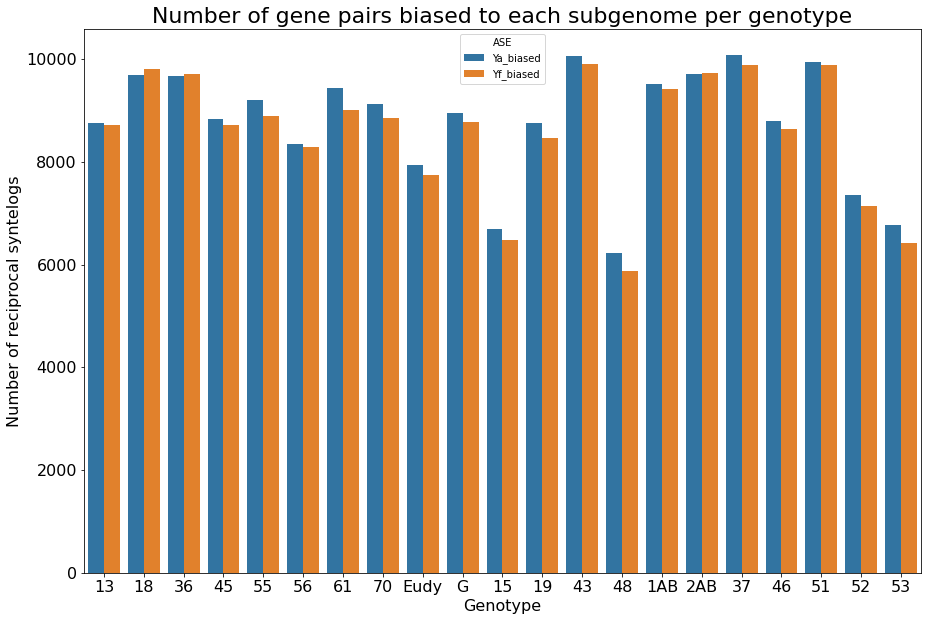

In [18]:
fig,ax = plt.subplots(figsize=(15,10))
#ax2 = ax.twiny()
sns.barplot(ax=ax,data=biascount,y="number of gene pairs",x="genotype",hue="ASE")
plt.title("Number of gene pairs biased to each subgenome per genotype",fontsize=22)
ax.tick_params(which="both",labelsize=16)
ax.set_ylabel("Number of reciprocal syntelogs",fontsize=16)
ax.set_xlabel("Genotype",fontsize=16)

plt.savefig("./deseq_ase_bygt_sortedphys.svg",dpi=200,bbox_inches="tight")

# make second axis per https://stackoverflow.com/questions/31803817/how-to-add-second-x-axis-at-the-bottom-of-the-first-one-in-matplotlib
#new_tick_locations = 
#fig.subplots_adjust(bottom=0.2)
#ax2.xaxis.set_ticks_position("bottom")
#ax2.xaxis.set_label_position("bottom")
#ax2.spines["bottom"].set_position(("axes", -0.15))
#ax2.set_frame_on(True)
#ax2.patch.set_visible(False)

## Plot CAM genes: numbers of genotypes (different physiologies) with ASE in each direction

In [21]:
# load CAM genes annotation
camgenes = pd.read_csv(os.path.join(dbase,"rna_insilico_genome","degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt"),sep="\t",header="infer")
camgenes.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [22]:
res["ASE"] = res["ASE"].str.split("_").str[0]

In [23]:
# put res into a longer format
## first, subset some columns
reslong = res[["syntelogID","Yf_GeneID","Ya_GeneID","genotype","ASE"]]
reslong.head()

,syntelogID,Yf_GeneID,Ya_GeneID,genotype,ASE
0,recip_syn2,YufilH1000007m.g,Yucal.01G000200.v2.1,18,Yf
1,recip_syn2,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB,Yf
2,recip_syn2,YufilH1000007m.g,Yucal.01G000200.v2.1,1AB,Yf
3,recip_syn2,YufilH1000007m.g,Yucal.01G000200.v2.1,19,Yf
4,recip_syn2,YufilH1000007m.g,Yucal.01G000200.v2.1,15,Yf


In [104]:
dflist = []
for i in ["Ya","Yf"]:
    df = reslong[reslong["ASE"]==i][[i+"_GeneID","syntelogID","genotype","ASE"]]
    df = df.rename(columns={i+"_GeneID":"GeneID","ASE":"subgenome"})
    df = df.merge(camgenes[["GeneID","subgenome","gene_abbr_unique","gene_abbr","Pathway"]])
    dflist.append(df)
hebcam = pd.concat(dflist)
hebcam.head()

,GeneID,syntelogID,genotype,subgenome,gene_abbr_unique,gene_abbr,Pathway
0,Yucal.01G165600.v2.1,recip_syn1434,2AB,Ya,Ya_bCA1234_1,bCA1234,CAM-dark
1,Yucal.01G165600.v2.1,recip_syn1434,1AB,Ya,Ya_bCA1234_1,bCA1234,CAM-dark
2,Yucal.01G165600.v2.1,recip_syn1434,15,Ya,Ya_bCA1234_1,bCA1234,CAM-dark
3,Yucal.01G165600.v2.1,recip_syn1434,36,Ya,Ya_bCA1234_1,bCA1234,CAM-dark
4,Yucal.01G165600.v2.1,recip_syn1434,45,Ya,Ya_bCA1234_1,bCA1234,CAM-dark


In [25]:
# create another dataframe to rename the syntelog pairs so we can fix the y axis of the plot
## create wide CAM data
dfl = []
for i in ["Ya","Yf"]:
    df = camgenes[camgenes["subgenome"]==i][["GeneID","gene_abbr_unique"]]
    df.rename(columns={"GeneID":i+"_GeneID","gene_abbr_unique":i+"_genename"},inplace=True)
    dfl.append(df)
for i in dfl:
    syn = syn.merge(i)
syn.head()

,Yf_GeneID,Ya_GeneID,syntelogID,Ya_genename,Yf_genename
0,YufilH1001781m.g,Yucal.01G077800.v2.1,recip_syn679,Ya_PPPC_1,Yf_PPPC_1
1,YufilH1003177m.g,Yucal.01G137500.v2.1,recip_syn1199,Ya_NADP-ME_1,Yf_NADP-ME_1
2,YufilH1003887m.g,Yucal.01G165600.v2.1,recip_syn1434,Ya_bCA1234_1,Yf_bCA1234_2
3,YufilH1011201m.g,Yucal.02G112700.v2.1,recip_syn3628,Ya_bCA1234_2,Yf_bCA1234_3
4,YufilH1011679m.g,Yucal.02G133400.v2.1,recip_syn3801,Ya_NADP-ME_2,Yf_NADP-ME_2


In [26]:
synnames = {}
for i in range(len(syn.index)):
    sid = syn.iloc[i,2]
    yan = syn.iloc[i,3].lstrip("Ya_")
    yfn = syn.iloc[i,4].lstrip("Yf_")
    if yan==yfn:
        synnames[sid] = yan+"_YaYf"
    else:
        if "_" in yan:
            yanum = yan.split("_")[1]
        else:
            yanum = ""
        if "_" in yfn:
            yfnum = yfn.split("_")[1]
        else:
            yfnum = ""
        synnames[sid] = yan.split("_")[0]+"_Ya"+yanum+"_Yf"+yfnum

In [27]:
hebcam["syntelog_name"] = hebcam["syntelogID"].map(synnames)

In [103]:
# redo syntelog naming: as of Mar. 26, 2026
rndict = json.load(open("../rename_camsyn_ya_to_synpairs.json"))

In [107]:
syn.head()

,Yf_GeneID,Ya_GeneID,syntelogID,Ya_genename,Yf_genename
0,YufilH1001781m.g,Yucal.01G077800.v2.1,recip_syn679,Ya_PPPC_1,Yf_PPPC_1
1,YufilH1003177m.g,Yucal.01G137500.v2.1,recip_syn1199,Ya_NADP-ME_1,Yf_NADP-ME_1
2,YufilH1003887m.g,Yucal.01G165600.v2.1,recip_syn1434,Ya_bCA1234_1,Yf_bCA1234_2
3,YufilH1011201m.g,Yucal.02G112700.v2.1,recip_syn3628,Ya_bCA1234_2,Yf_bCA1234_3
4,YufilH1011679m.g,Yucal.02G133400.v2.1,recip_syn3801,Ya_NADP-ME_2,Yf_NADP-ME_2


In [119]:
type(y[0])

str

In [129]:
# create a dict of syntelogID to these new names
synname2 = {}
for k in rndict.keys():
    if k in list(syn["Ya_genename"]):
        synid = syn.query("Ya_genename==@k")["syntelogID"]
        #print(synid)
        synid = synid[int(synid.index[0])]
        #print(synid)
        synname2[synid] = rndict[k]

In [130]:
synname2

{'recip_syn1434': 'Ya_bCA1234_1/Yf_bCA1234_2',
 'recip_syn3628': 'Ya_bCA1234_2/Yf_bCA1234_3',
 'recip_syn7619': 'Ya_bCA5_1/Yf_bCA5_1',
 'recip_syn13926': 'Ya_bCA5_2/Yf_bCA5_4',
 'recip_syn6335': 'Ya_NAD-MDH-cp_1/Yf_NAD-MDH-cp_1',
 'recip_syn8179': 'Ya_NAD-MDH-cp_2/Yf_NAD-MDH-cp_2',
 'recip_syn11445': 'Ya_NAD-MDH-cp_3/Yf_NAD-MDH-cp_3',
 'recip_syn25868': 'Ya_NAD-MDH-cp_4/Yf_NAD-MDH-cp_4',
 'recip_syn6893': 'Ya_NAD-MDH-ct_1/Yf_NAD-MDH-ct_2',
 'recip_syn23442': 'Ya_NAD-MDH-ct_2/Yf_NAD-MDH-ct_3',
 'recip_syn24607': 'Ya_NAD-MDH-ct_3/Yf_NAD-MDH-ct_4',
 'recip_syn23299': 'Ya_NADP-MDH/Yf_NADP-MDH_1',
 'recip_syn14735': 'Ya_BPPC_1/Yf_BPPC',
 'recip_syn679': 'Ya_PPPC_1/Yf_PPPC_1',
 'recip_syn12457': 'Ya_PPPC_2/Yf_PPPC_2',
 'recip_syn14378': 'Ya_PPPC_3/Yf_PPPC_3',
 'recip_syn28164': 'Ya_PPPC_4/Yf_PPPC_4',
 'recip_syn9117': 'Ya_PPCK_2/Yf_PPCK_1',
 'recip_syn10390': 'Ya_PPCK_4/Yf_PPCK_2',
 'recip_syn23445': 'Ya_PPCK_6/Yf_PPCK_4',
 'recip_syn24603': 'Ya_PPCK_7/Yf_PPCK_5',
 'recip_syn6047': 'Ya_NAD-M

In [131]:
len(hebcam["syntelogID"].unique())

28

In [133]:
hebcam["syntelog_name"] = hebcam["syntelogID"].map(synname2)

In [135]:
gaumap = {}
for i in hebcam["gene_abbr_unique"].unique():
    if "Ya" in i:
        gaumap[i] = i.lstrip("Ya_")
    elif "Yf" in i:
        gaumap[i] = i.lstrip("Yf_")
hebcam["gene_abbr_unique"] = hebcam["gene_abbr_unique"].map(gaumap)

In [136]:
hebcam.head()

,GeneID,syntelogID,genotype,subgenome,gene_abbr_unique,gene_abbr,Pathway,syntelog_name
0,Yucal.01G165600.v2.1,recip_syn1434,2AB,Ya,bCA1234_1,bCA1234,CAM-dark,Ya_bCA1234_1/Yf_bCA1234_2
1,Yucal.01G165600.v2.1,recip_syn1434,1AB,Ya,bCA1234_1,bCA1234,CAM-dark,Ya_bCA1234_1/Yf_bCA1234_2
2,Yucal.01G165600.v2.1,recip_syn1434,15,Ya,bCA1234_1,bCA1234,CAM-dark,Ya_bCA1234_1/Yf_bCA1234_2
3,Yucal.01G165600.v2.1,recip_syn1434,36,Ya,bCA1234_1,bCA1234,CAM-dark,Ya_bCA1234_1/Yf_bCA1234_2
4,Yucal.01G165600.v2.1,recip_syn1434,45,Ya,bCA1234_1,bCA1234,CAM-dark,Ya_bCA1234_1/Yf_bCA1234_2


In [137]:
hebcam["CAMphys"] = hebcam["genotype"].map(phys)

In [138]:
camhebcounts = hebcam.groupby(["syntelog_name","subgenome","CAMphys"]).count()[["GeneID"]].reset_index().rename(columns={"GeneID":"count"})

In [139]:
camhebcounts.head()

,syntelog_name,subgenome,CAMphys,count
0,Ya_BPPC_1/Yf_BPPC,Ya,C3,1
1,Ya_BPPC_1/Yf_BPPC,Ya,possible_fac_CAM,1
2,Ya_BPPC_1/Yf_BPPC,Yf,C3,5
3,Ya_BPPC_1/Yf_BPPC,Yf,facultative_CAM,1
4,Ya_BPPC_1/Yf_BPPC,Yf,possible_fac_CAM,3


In [140]:
camhebcounts.sort_values(by=["syntelog_name"],ascending=True,inplace=True)

In [141]:
camhebcounts["sgphys"] = camhebcounts["subgenome"]+"_"+camhebcounts["CAMphys"]

In [142]:
# convert to a wide format
widecounts = pd.pivot(camhebcounts, index="syntelog_name", columns='sgphys', values='count')
widecounts.head()

sgphys,Ya_C3,Ya_facultative_CAM,Ya_possible_fac_CAM,Yf_C3,Yf_facultative_CAM,Yf_possible_fac_CAM
syntelog_name,,,,,,
Ya_BPPC_1/Yf_BPPC,1.0,NaN,1.0,5.0,1.0,3.0
Ya_NAD-MDH-cp_1/Yf_NAD-MDH-cp_1,7.0,NaN,3.0,NaN,NaN,NaN
Ya_NAD-MDH-cp_3/Yf_NAD-MDH-cp_3,NaN,NaN,NaN,10.0,4.0,7.0
Ya_NAD-MDH-cp_4/Yf_NAD-MDH-cp_4,9.0,3.0,7.0,NaN,NaN,NaN
Ya_NAD-MDH-ct_1/Yf_NAD-MDH-ct_2,NaN,NaN,NaN,10.0,4.0,7.0


In [143]:
widecounts.fillna(0,inplace=True)

In [144]:
custompal = {
    "Ya_C3":"skyblue",
    "Ya_facultative_CAM":"navy",
    "Ya_possible_fac_CAM":"royalblue",
    "Yf_C3":"coral",
    "Yf_facultative_CAM":"saddlebrown",
    "Yf_possible_fac_CAM":"orangered"
}

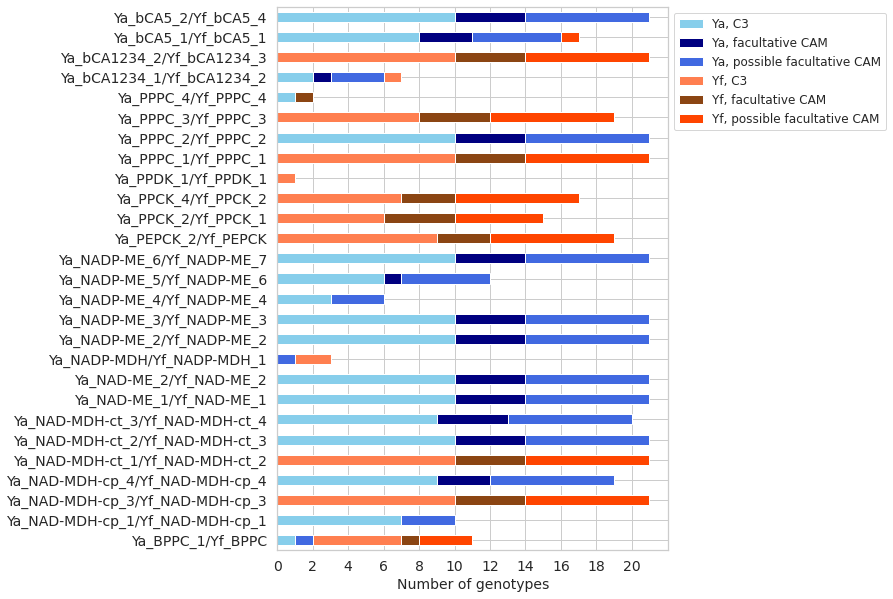

In [145]:
sns.set_theme(style="whitegrid")
fig,ax = plt.subplots(figsize=(7,10))
widecounts.plot(kind="barh",ax=ax,stacked=True,colormap=LinearSegmentedColormap.from_list("custom",list(custompal.values())))
# move legend outside plot & customize
plt.legend(bbox_to_anchor=(1,1),labels=["Ya, C3","Ya, facultative CAM","Ya, possible facultative CAM",
                                       "Yf, C3","Yf, facultative CAM","Yf, possible facultative CAM"],
          fontsize=12)
# customize axis labels
ax.tick_params(which="both",labelsize=14)
plt.ylabel("")
plt.xlabel("Number of genotypes",fontsize=14)
plt.xticks(ticks=range(0,21,2))

plt.savefig("./camgenes_ase_gtnum_byphys.png",dpi=200,bbox_inches="tight")
plt.savefig("./camgenes_ase_gtnum_byphys.svg",dpi=200,bbox_inches="tight")
plt.savefig("./camgenes_ase_gtnum_byphys.pdf",dpi=200,bbox_inches="tight")

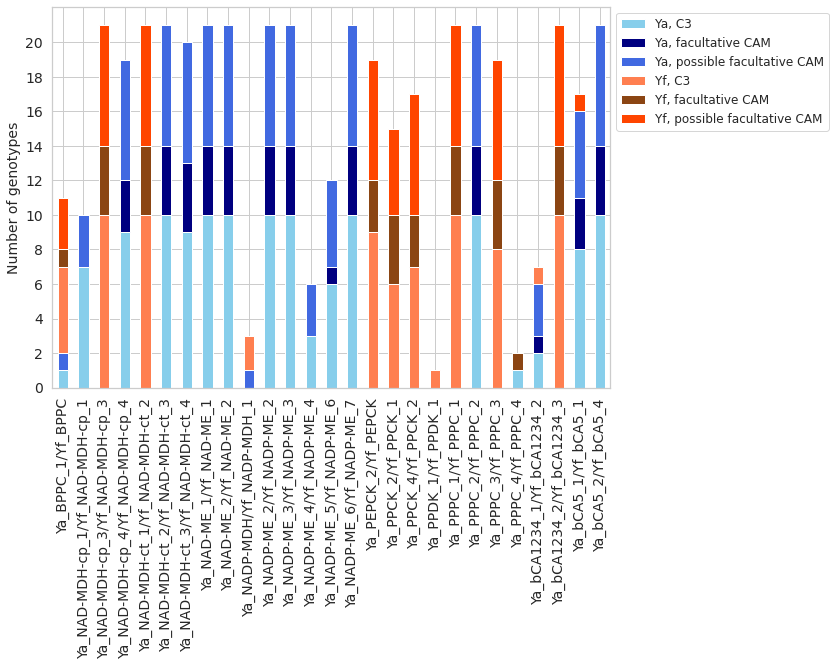

In [146]:
# re-plot in a horizontal format
sns.set_theme(style="whitegrid")
fig,ax = plt.subplots(figsize=(10,7))
widecounts.plot(kind="bar",ax=ax,stacked=True,colormap=LinearSegmentedColormap.from_list("custom",list(custompal.values())))
# move legend outside plot & customize
plt.legend(bbox_to_anchor=(1,1),labels=["Ya, C3","Ya, facultative CAM","Ya, possible facultative CAM",
                                       "Yf, C3","Yf, facultative CAM","Yf, possible facultative CAM"],
          fontsize=12)
# customize axis labels
ax.tick_params(which="both",labelsize=14)
plt.ylabel("Number of genotypes",fontsize=14)
plt.xlabel("")
plt.yticks(ticks=range(0,21,2))

plt.savefig("./camgenes_ase_gtnum_byphys_horizontal.png",dpi=200,bbox_inches="tight")
plt.savefig("./camgenes_ase_gtnum_byphys_horizontal.svg",dpi=200,bbox_inches="tight")
plt.savefig("./camgenes_ase_gtnum_byphys_horizontal.pdf",dpi=200,bbox_inches="tight")

## Plot number of ASE CAM genes by genotype

In [33]:
hebcam.head()

,GeneID,syntelogID,genotype,subgenome,gene_abbr_unique,gene_abbr,Pathway,syntelog_name,CAMphys
0,Yucal.01G165600.v2.1,recip_syn1434,2AB,Ya,bCA1234_1,bCA1234,CAM-dark,bCA1234_Ya1_Yf2,possible_fac_CAM
1,Yucal.01G165600.v2.1,recip_syn1434,1AB,Ya,bCA1234_1,bCA1234,CAM-dark,bCA1234_Ya1_Yf2,possible_fac_CAM
2,Yucal.01G165600.v2.1,recip_syn1434,15,Ya,bCA1234_1,bCA1234,CAM-dark,bCA1234_Ya1_Yf2,facultative_CAM
3,Yucal.01G165600.v2.1,recip_syn1434,36,Ya,bCA1234_1,bCA1234,CAM-dark,bCA1234_Ya1_Yf2,C3
4,Yucal.01G165600.v2.1,recip_syn1434,45,Ya,bCA1234_1,bCA1234,CAM-dark,bCA1234_Ya1_Yf2,C3


In [35]:
camcount = hebcam.groupby(["CAMphys","genotype","subgenome","gene_abbr"]).count().reset_index()[["CAMphys","genotype","subgenome",
                                                                                     "gene_abbr","GeneID"]]

In [36]:
camcount.head()

,CAMphys,genotype,subgenome,gene_abbr,GeneID
0,C3,13,Ya,NAD-MDH-cp,2
1,C3,13,Ya,NAD-MDH-ct,1
2,C3,13,Ya,NAD-ME,3
3,C3,13,Ya,NADP-ME,5
4,C3,13,Ya,PPPC,1


In [160]:
# reset to a wide format & split by subgenome into 2 different dataframes
def to_wide(sg):
    df = camcount[camcount["subgenome"]==sg]
    df.sort_values(by=["CAMphys","genotype"],inplace=True)
    df2 = df.drop(["CAMphys","subgenome"],axis=1)
    #print(df.head(15))
    wide = pd.pivot(df2,index="genotype",columns="gene_abbr",values="GeneID")
    wide = wide.reset_index()
    wide["CAMphys"] = wide["genotype"].map(phys)
    wide = wide.sort_values(by=["CAMphys","genotype"],ascending=True)
    #print(wide.head())
    wide = wide.set_index("genotype").drop("CAMphys",axis=1)
    return wide.fillna(0)

In [161]:
yacamct = to_wide("Ya")
yfcamct = to_wide("Yf")

/tmp/ipykernel_1560/743347306.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=["CAMphys","genotype"],inplace=True)
/tmp/ipykernel_1560/743347306.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=["CAMphys","genotype"],inplace=True)


In [162]:
yacamct.head()

gene_abbr,BPPC,NAD-MDH-cp,NAD-MDH-ct,NAD-ME,NADP-MDH,NADP-ME,PPPC,bCA1234,bCA5
genotype,,,,,,,,,
13,0.0,2.0,1.0,3.0,0.0,5.0,1.0,0.0,1.0
18,0.0,2.0,2.0,3.0,0.0,4.0,2.0,0.0,2.0
36,0.0,2.0,2.0,3.0,0.0,4.0,1.0,1.0,2.0
45,0.0,2.0,2.0,3.0,0.0,5.0,1.0,1.0,1.0
55,0.0,2.0,2.0,3.0,0.0,3.0,1.0,0.0,2.0


In [163]:
yfcamct.head()

gene_abbr,BPPC,NAD-MDH-cp,NAD-MDH-ct,NADP-MDH,PEPCK,PPCK,PPDK,PPPC,bCA1234,bCA5
genotype,,,,,,,,,,
13,1.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0
18,1.0,1.0,1.0,1.0,1.0,2.0,0.0,2.0,2.0,0.0
36,1.0,1.0,1.0,0.0,1.0,1.0,0.0,2.0,1.0,0.0
45,1.0,1.0,1.0,1.0,0.0,2.0,0.0,2.0,1.0,0.0
55,0.0,1.0,1.0,0.0,1.0,1.0,0.0,2.0,1.0,0.0


In [63]:
for c in yfcamct.columns:
    if c not in list(yacamct.columns):
        print(c)

PEPCK
PPCK
PPDK


In [64]:
for c in yacamct.columns:
    if c not in list(yfcamct.columns):
        print(c)

NAD-ME
NADP-ME


In [164]:
colorderya = []
colorderyf = []
for c in yacamct.columns:
    if c in list(yfcamct.columns):
        colorderya.append(c)
        colorderyf.append(c)

for c in yacamct.columns:
    if c not in list(yfcamct.columns):
        colorderya.append(c)
        
for c in yfcamct.columns:
    if c not in list(yacamct.columns):
        colorderyf.append(c)

In [165]:
len(colorderya)

9

In [166]:
len(colorderyf)

10

In [167]:
yacamct = yacamct[colorderya]
yfcamct = yfcamct[colorderyf]

In [168]:
# set up colormaps where the first 7 colors match
cm1 = ["tab:blue","tab:orange","tab:green","tab:purple","tab:cyan","saddlebrown","midnightblue",
      "darkslategray","firebrick"]
cm2 = ["tab:blue","tab:orange","tab:green","tab:purple","tab:cyan","saddlebrown","midnightblue",
       "teal","gray","darkmagenta"]

In [169]:
# make colormap objects
yacmap = LinearSegmentedColormap.from_list("Ya",cm1)
yfcmap = LinearSegmentedColormap.from_list("Yf",cm2)

In [170]:
yacamct.head()

gene_abbr,BPPC,NAD-MDH-cp,NAD-MDH-ct,NADP-MDH,PPPC,bCA1234,bCA5,NAD-ME,NADP-ME
genotype,,,,,,,,,
13,0.0,2.0,1.0,0.0,1.0,0.0,1.0,3.0,5.0
18,0.0,2.0,2.0,0.0,2.0,0.0,2.0,3.0,4.0
36,0.0,2.0,2.0,0.0,1.0,1.0,2.0,3.0,4.0
45,0.0,2.0,2.0,0.0,1.0,1.0,1.0,3.0,5.0
55,0.0,2.0,2.0,0.0,1.0,0.0,2.0,3.0,3.0


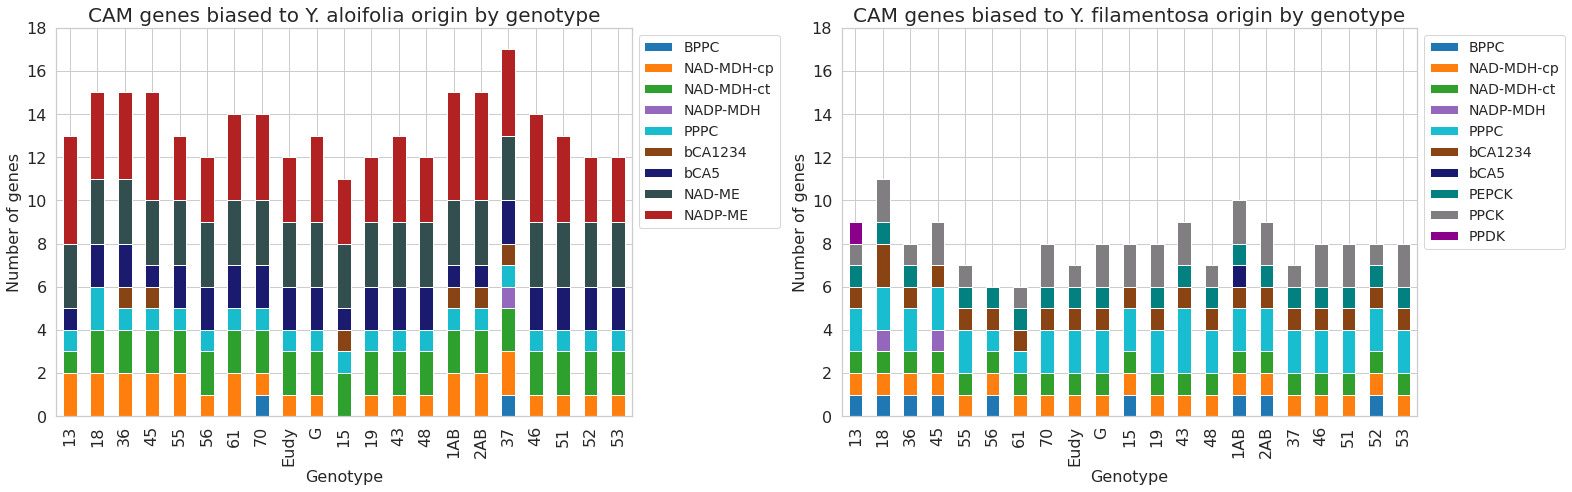

In [171]:
sns.set_theme(style="whitegrid")
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(22,7),sharex=True)
yacamct.plot(kind="bar",ax=ax[0],stacked=True,colormap=yacmap)
yfcamct.plot(kind="bar",ax=ax[1],stacked=True,colormap=yfcmap)

ax[0].tick_params(which="both",labelsize=16)
ax[0].set_xlabel("Genotype",fontsize=16)
ax[0].set_ylabel("Number of genes",fontsize=16)
ax[0].set_ylim(0,18)
ax[0].set_title("CAM genes biased to Y. aloifolia origin by genotype",fontsize=20)
ax[0].legend(bbox_to_anchor=(1,1),fontsize=14)

ax[1].tick_params(which="both",labelsize=16)
ax[1].set_xlabel("Genotype",fontsize=16)
ax[1].set_ylabel("Number of genes",fontsize=16)
ax[1].set_ylim(0,18)
ax[1].set_title("CAM genes biased to Y. filamentosa origin by genotype",fontsize=20)
ax[1].legend(bbox_to_anchor=(1,1),fontsize=14)

fig.tight_layout()
plt.savefig("./CAM_ASE_bygt.png",dpi=300,bbox_inches="tight")
plt.savefig("./CAM_ASE_bygt.svg",dpi=300,bbox_inches="tight")
plt.savefig("./CAM_ASE_bygt.pdf",dpi=300,bbox_inches="tight")

In [175]:
cct = hebcam.groupby(["genotype","subgenome"]).count().reset_index()[["genotype",
                                                               "subgenome",
                                                               "GeneID"]]

In [176]:
cct.sort_values(by="GeneID")

,genotype,subgenome,GeneID
33,56,Yf,6
35,61,Yf,6
23,48,Yf,7
39,Eudy,Yf,7
31,55,Yf,7
15,37,Yf,7
25,51,Yf,8
29,53,Yf,8
21,46,Yf,8
27,52,Yf,8
